In [2]:
%load_ext autoreload
%autoreload 2

In [1]:
"""
1. Injection of global noise via phase shifts and
by frequency offsets.

2. Injection of global and local noise via single
addressing beams causing stark shifts.

"""

import graph_style as gs
import fig_helper as fh
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

gs.set_graph_style(1)

$\theta_{\mathrm{com}}$: 0.6226 ± 0.0216
$\theta_{\mathrm{diff}}$: 0.0411 ± 0.0060
Angle between axes ($\theta_{\mathrm{ax}}$): 1.3044 ± 0.4094
$\epsilon_{\mathrm{SP}}$: 0.0034 ± 0.0133


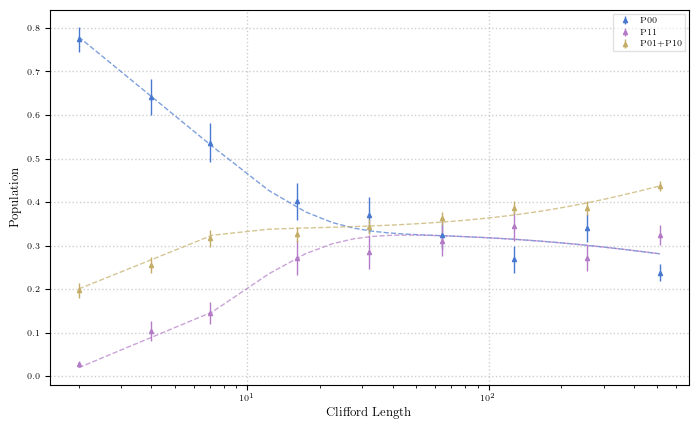

In [3]:
# Plot single RB decay and fit to model
def plot_data_fit(df, model_func, popt):
    plt.errorbar(df["Clifford Length"], df["P00"], yerr=df["P00 Std"], fmt="^", label="P00", color=gs.get_color(0))
    #plt.errorbar(df["Clifford Length"], df["P01"], yerr=df["P01 Std"], fmt="^", label="P01", color=gs.get_color(1))
    #plt.errorbar(df["Clifford Length"], df["P10"], yerr=df["P10 Std"], fmt="^", label="P10", color=gs.get_color(2))
    plt.errorbar(df["Clifford Length"], df["P11"], yerr=df["P11 Std"], fmt="^", label="P11", color=gs.get_color(3))
    P0110 = df["P01"] + df["P10"]
    P0110_std = np.sqrt(df["P01 Std"]**2 + df["P10 Std"]**2)
    plt.errorbar(df["Clifford Length"], P0110, yerr=P0110_std, fmt="^", label="P01+P10", color=gs.get_color(4))

    x_fit = np.linspace(min(df["Clifford Length"]), max(df["Clifford Length"]), 100)
    P_fit = model_func(x_fit, *popt).reshape(4, -1)
    plt.plot(x_fit, P_fit[0], color=gs.get_color(0), alpha=gs.get_alpha())
    #plt.plot(x_fit, P_fit[1], color=gs.get_color(1), alpha=gs.get_alpha())
    #plt.plot(x_fit, P_fit[2], color=gs.get_color(2), alpha=gs.get_alpha())
    plt.plot(x_fit, P_fit[3], color=gs.get_color(3), alpha=gs.get_alpha())
    P0110_fit = P_fit[1] + P_fit[2]
    plt.plot(x_fit, P0110_fit, color=gs.get_color(4), alpha=gs.get_alpha())
    # log x
    plt.xscale("log")

    plt.xlabel("Clifford Length")
    plt.ylabel("Population")
    plt.legend()
    plt.show()

#date = "2026-01-07"
date = "2026-02-19"
rid = 94053# 88856
sim_outcomes = [1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, ]
# 
sim_outcomes = [0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, ]
#m = fh.PTMModel()
m = fh.GTModel()


df, popt, pcov = m.rb_to_fits(date, rid, sim_outcomes)
param1, param2, param3, param4 = popt
param1_err, param2_err, param3_err, param4_err = np.sqrt(np.diag(pcov))
print(f"{m.p1_name}: {param1:.4f} ± {param1_err:.4f}")
print(f"{m.p2_name}: {param2:.4f} ± {param2_err:.4f}")
print(f"{m.p3_name}: {param3:.4f} ± {param3_err:.4f}")
print(f"{m.p4_name}: {param4:.4f} ± {param4_err:.4f}")

plot_data_fit(df, m.model, popt)

Fitted a: 0.0421 ± 0.0004
Fitted y0: 0.1011 ± 0.0016
Fitted detuning offset: 0.9589 ± 0.0340


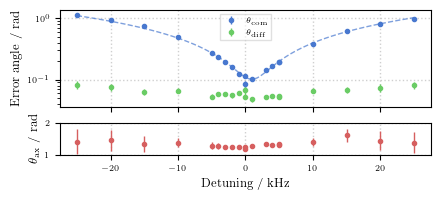

In [4]:
# Plot injected noise vs. fitted noise for global phase noise
date = "2026-01-19"
rids = [91166, 91167, 91168, 91169, 91170, 91171, 91172, 91173, 91174, 91175, 91176, 91177, 91178, 91179, 91180, 91181, 91182, 91183, 91184, 91185, 91186, 91194, 91195, 91196, 91197, 91198, 91199, 91200, 91201, 91202, 91203, 91204 ]
errs = [50.0, -40.0, 35.0, -15.0, -25.0, 25.0, -20.0, -10.0, 45.0, -30.0, 0.0, -45.0, 30.0, -35.0, 20.0, 15.0, 40.0, 10.0, -5.0, -50.0, 5.0, 3.0, 1.0, 0.0, -4.0, -2.0, -1.0, 2.0, -5.0, 5.0, -3.0, 4.0, ]
errs = np.array(errs)
filt_errs_map = abs(errs) < 30.0
errs = errs[filt_errs_map]
rids = np.array(rids)[filt_errs_map]
failed_rids_map = [rid not in [91200, 91201] for rid in rids]
rids = rids[failed_rids_map]
errs = errs[failed_rids_map]

sim_outcomes = [0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, ]
m = fh.PTMModel()
m = fh.GTModel()

param1, param2, param3, param4 = m.fit_mult_rbs(date, rids, sim_outcomes)

popt, pcov = curve_fit(fh.detuning_model, errs, [t[0] for t in param1], sigma=[t[1] for t in param1], absolute_sigma=True, p0=[0.01, 1.0, 0.0], bounds=([0.0, 0.0, -10.0], [1.0, 100.0, 10.0]))
print(f"Fitted a: {popt[1]:.4f} ± {np.sqrt(pcov[1, 1]):.4f}")
print(f"Fitted y0: {popt[0]:.4f} ± {np.sqrt(pcov[0, 0]):.4f}")
print(f"Fitted detuning offset: {popt[2]:.4f} ± {np.sqrt(pcov[2, 2]):.4f}")
x_fit = np.linspace(min(errs), max(errs), 100)
I_fit = fh.detuning_model(x_fit, *popt)

margin = gs.get_margin()
fig_width = gs.get_phi() / (gs.get_phi() + 1) * gs.get_fig_width() - margin
fig_height = 0.7 / (gs.get_phi() + 1) * gs.get_fig_width()

if m.name == "GT":
    fig, (ax, ax2) = plt.subplots(ncols=1, nrows=2, figsize=(fig_width, fig_height), height_ratios=[3,1],
                            layout="constrained")
else:
    fig, ax = plt.subplots(ncols=1, nrows=1, figsize=(fig_width, fig_height), layout="constrained")

ax.errorbar(errs, [t[0] for t in param1], yerr=[t[1] for t in param1], fmt="o", label=m.p1_name, color=gs.get_color(0))
ax.errorbar(errs, [t[0] for t in param2], yerr=[t[1] for t in param2], fmt="o", label=m.p2_name, color=gs.get_color(1))
#ax.errorbar(errs, [t[0] for t in param4], yerr=[t[1] for t in param4], fmt="o", label=m.p4_name, color=gs.get_color(3))
ax.plot(x_fit, I_fit, color=gs.get_color(0), alpha=gs.get_alpha())

ax.set_ylabel("Error angle / rad")
ax.legend(loc="upper center")
# set log y
ax.set_yscale("log")
# remove x labels for the upper plot
ax.set_xticklabels([])
#gs.place_letter(fig, "c")

if m.name == "GT":
    ax_i = ax2
    ax_i.set_ylabel("$\\theta_{\\mathrm{ax}}$ / rad")
    ax_i.set_ylim(1., 2.)
else:
    ax_i = ax

ax_i.set_xlabel("Detuning / kHz")
ax_i.errorbar(errs, [t[0] for t in param3], yerr=[t[1] for t in param3], fmt="o", label=m.p3_name, color=gs.get_color(2))
# save the figure
f_path = "..\\pdf_figure\\f2_rb_detuning.pdf"
fig.savefig(f_path)



Fitted a: 0.9574 ± 0.0085
Fitted y0: 0.1074 ± 0.0008


<ErrorbarContainer object of 3 artists>

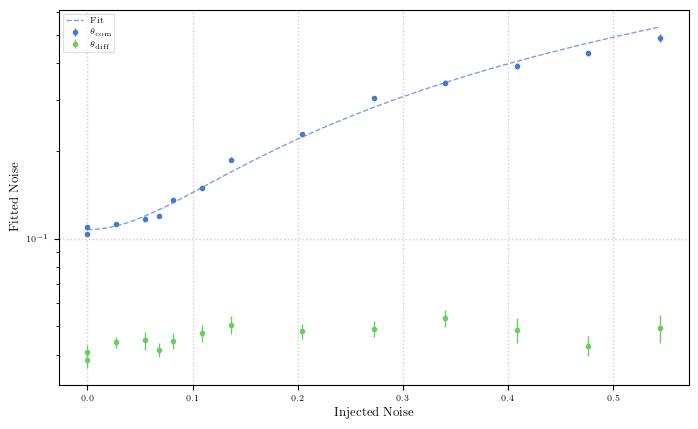

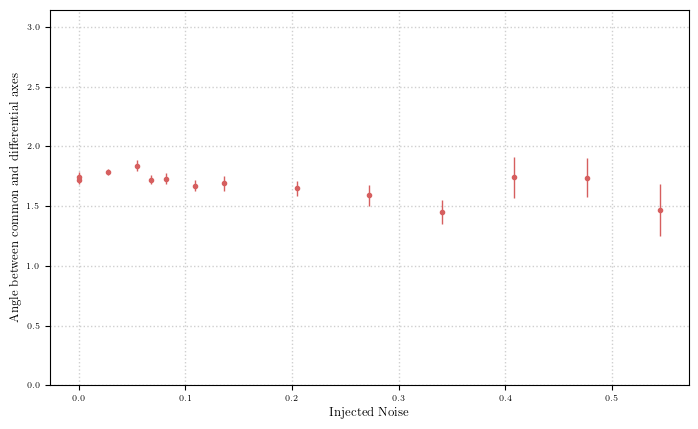

In [68]:
# Plot injected noise vs. fitted noise for global phase noise
date = "2026-01-07"
rids = [88856, 88857, 88858, 88859, 88860, 88862, 88863, 88864, 88866, 88867, 88868, 88869, 88870, 88871]
errs = [0.005, 0.02,  0.035, 0.04,  0.03,  0.015, 0.025, 0., 0.008, 0.01,  0.002, 0.006, 0.004, 0.   ]
pi2_to_cliff = 2.16667
errs = [err * pi2_to_cliff*2*np.pi for err in errs]
sim_outcomes = [1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, ]
m = fh.PTMModel()
m = fh.GTModel()

param1, param2, param3, param4 = m.fit_mult_rbs(date, rids, sim_outcomes)

popt, pcov = curve_fit(fh.inject_model, errs, [t[0] for t in param1], sigma=[t[1] for t in param1], absolute_sigma=True, p0=[0.01, 1.0], bounds=([0.0, 0.0], [1.0, 100.0]))
print(f"Fitted a: {popt[1]:.4f} ± {np.sqrt(pcov[1, 1]):.4f}")
print(f"Fitted y0: {popt[0]:.4f} ± {np.sqrt(pcov[0, 0]):.4f}")
x_fit = np.linspace(min(errs), max(errs), 100)
I_fit = fh.inject_model(x_fit, *popt)
plt.errorbar(errs, [t[0] for t in param1], yerr=[t[1] for t in param1], fmt="o", label=m.p1_name, color=gs.get_color(0))
plt.errorbar(errs, [t[0] for t in param2], yerr=[t[1] for t in param2], fmt="o", label=m.p2_name, color=gs.get_color(1))
#plt.errorbar(errs, [t[0] for t in param4], yerr=[t[1] for t in param4], fmt="o", label=m.p4_name, color=gs.get_color(3))
plt.plot(x_fit, I_fit, label="Fit", color=gs.get_color(0), alpha=gs.get_alpha())
#set log y
plt.yscale("log")
plt.xlabel("Injected Noise")
plt.ylabel("Fitted Noise")
plt.legend()
if m.name == "GT":
    plt.figure("Rot axis / rad")
    plt.xlabel("Injected Noise")
    plt.ylim(0.0, np.pi)
    plt.ylabel("Angle between common and differential axes")
plt.errorbar(errs, [t[0] for t in param3], yerr=[t[1] for t in param3], fmt="o", label=m.p3_name, color=gs.get_color(2))



Fitted a: 0.7497 ± 0.0073
Fitted y0: 0.1291 ± 0.0011
Fitted a: 0.7242 ± 0.0189
Fitted y0: 0.0599 ± 0.0022


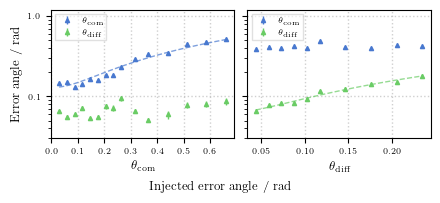

In [74]:
# Plot injected noise vs. fitted noise for global stark shift noise
date = "2026-01-29"
rids = [92520, 92521, 92522, 92523, 92524, 92525, 92526, 92527, 92528, 92533, 92535, 92536, 92537, 92540, 92541]
errs = [0.004, 0.036, 0.028, 0.016, 0.012, 0.008, 0.032, 0.024, 0.02, 0.07, 0.09, 0.05, 0.06, 0.043, 0.08]
pi2_to_cliff = 1.16667
errs = [err * pi2_to_cliff*2*np.pi for err in errs]
sim_outcomes = [1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, ]
m = fh.PTMModel()
m = fh.GTModel()

param1, param2, param3, param4 = m.fit_mult_rbs(date, rids, sim_outcomes)

popt, pcov = curve_fit(fh.inject_model, errs, [t[0] for t in param1], sigma=[t[1] for t in param1], absolute_sigma=True, p0=[0.01, 1.0], bounds=([0.0, 0.0], [1.0, 100.0]))
print(f"Fitted a: {popt[1]:.4f} ± {np.sqrt(pcov[1, 1]):.4f}")
print(f"Fitted y0: {popt[0]:.4f} ± {np.sqrt(pcov[0, 0]):.4f}")
x_fit = np.linspace(min(errs), max(errs), 100)
I_fit = fh.inject_model(x_fit, *popt)
margin = gs.get_margin()
fig_width = gs.get_phi() / (gs.get_phi() + 1) * gs.get_fig_width() - margin
fig_height = 1.15 / (gs.get_phi() + 1) * gs.get_fig_width() * 1/gs.get_phi()

if m.name == "GT":
    # fig, ([ax, ax2], [ax3, ax4]) = plt.subplots(ncols=2, nrows=2, figsize=(fig_width, fig_height), height_ratios=[3,1],
    #                         layout="constrained")
    fig, (ax, ax2) = plt.subplots(ncols=2, nrows=1, figsize=(fig_width, fig_height),
                            layout="constrained")
else:
    fig, ax = plt.subplots(ncols=1, nrows=1, figsize=(fig_width, fig_height), layout="constrained")

ax.errorbar(errs, [t[0] for t in param1], yerr=[t[1] for t in param1], fmt="^", label=m.p1_name, color=gs.get_color(0))
ax.errorbar(errs, [t[0] for t in param2], yerr=[t[1] for t in param2], fmt="^", label=m.p2_name, color=gs.get_color(1))
#ax.errorbar(errs, [t[0] for t in param4], yerr=[t[1] for t in param4], fmt="o", label=m.p4_name, color=gs.get_color(3))
ax.plot(x_fit, I_fit, color=gs.get_color(0), alpha=gs.get_alpha())
# set log y
ax.set_yscale("log")
ax.set_ylabel("Error angle / rad")
ax.legend(loc="upper left")
#gs.place_letter(fig, "d")
#gs.place_letter(fig, "e", x=0.52)

# if m.name == "GT":
#     ax_i = ax3
#     ax_i.set_ylabel("$\\theta_{ax}$ / rad")
#     ax_i.set_ylim(1.2, 2.2)
# else:
#     ax_i = ax

#ax.set_xlabel("Injected Common Error / rad")
# ax_i.errorbar(errs, [t[0] for t in param3], yerr=[t[1] for t in param3], fmt="o", label=m.p3_name, color=gs.get_color(2))



# Plot injected noise vs. fitted noise for local stark shift noise
date = "2026-01-30"
rids = [92774, 92775, 92776, 92777, 92778, 92779, 92780, 92781, 92782, 92783]
errs = [0.028, 0.016, 0.012, 0.008, 0.032, 0.024, 0.02, 0.01, 0.014, 0.006, ]
pi2_to_cliff = 1.16667
errs = [err * pi2_to_cliff*2*np.pi for err in errs]
sim_outcomes = [1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, ]
m = fh.PTMModel()
m = fh.GTModel()

param1, param2, param3, param4 = m.fit_mult_rbs(date, rids, sim_outcomes)

if m.name == "GT":
    popt, pcov = curve_fit(fh.inject_model, errs, [t[0] for t in param2], sigma=[t[1] for t in param2], absolute_sigma=True, p0=[0.01, 1.0], bounds=([0.0, 0.0], [1.0, 100.0]))
    print(f"Fitted a: {popt[1]:.4f} ± {np.sqrt(pcov[1, 1]):.4f}")
    print(f"Fitted y0: {popt[0]:.4f} ± {np.sqrt(pcov[0, 0]):.4f}")
elif m.name == "PTM":
    popt, pcov = curve_fit(fh.inject_model, errs, [t[0] for t in param2], sigma=[t[1] for t in param2], absolute_sigma=True, p0=[0.01, 1.0], bounds=([0.0, 0.0], [1.0, 100.0]))
    print(f"Fitted a_l1: {popt[1]:.4f} ± {np.sqrt(pcov[1, 1]):.4f}")
    print(f"Fitted theta_l1_0: {popt[0]:.4f} ± {np.sqrt(pcov[0, 0]):.4f}")
    x_fit = np.linspace(min(errs), max(errs), 100)
    I_fit = fh.inject_model(x_fit, *popt)
    plt.plot(x_fit, I_fit, label="Fit", color=gs.get_color(0), alpha=gs.get_alpha())
    popt, pcov = curve_fit(fh.inject_model, errs, [t[0] for t in param3], sigma=[t[1] for t in param3], absolute_sigma=True, p0=[0.01, 1.0], bounds=([0.0, 0.0], [1.0, 100.0]))
    print(f"Fitted a_l2: {popt[1]:.4f} ± {np.sqrt(pcov[1, 1]):.4f}")
    print(f"Fitted theta_l2_0: {popt[0]:.4f} ± {np.sqrt(pcov[0, 0]):.4f}")
x_fit = np.linspace(min(errs), max(errs), 100)
I_fit = fh.inject_model(x_fit, *popt)
ax2.errorbar(errs, [t[0] for t in param1], yerr=[t[1] for t in param1], fmt="^", label=m.p1_name, color=gs.get_color(0))
ax2.errorbar(errs, [t[0] for t in param2], yerr=[t[1] for t in param2], fmt="^", label=m.p2_name, color=gs.get_color(1))
#ax2.errorbar(errs, [t[0] for t in param4], yerr=[t[1] for t in param4], fmt="o", label=m.p4_name, color=gs.get_color(3))
ax2.plot(x_fit, I_fit, color=gs.get_color(1), alpha=gs.get_alpha())

# link with ax
ax.set_ylim(0.03, 1.2) 
ax2.set_ylim(0.03, 1.2) 

# plt.subplots_adjust(wspace=0.05)
ax2.set_yscale("log")
ax2.set_yticklabels([])
# # turn off ticks
ax2.set_yticks([0.1, 1.0])
ax.set_yticklabels([])

# set y tick labels to be 0.1, 1.0
ax.set_yticks([0.1, 1.0])
ax.set_yticklabels(["0.1", "1.0"])

ax2.legend(loc="upper left")
ax.legend(loc="upper left")

# if m.name == "GT":
#     ax_i = ax4
#     ax_i.set_ylim(1.2, 2.2)
#     # ax_i.set_yticklabels([])
#     # ax_i.set_yticks([])
# else:
#     ax_i = ax
fig.supxlabel('Injected error angle / rad', fontsize=9)
ax.set_xlabel("$\\theta_{\\mathrm{com}}$")
ax2.set_xlabel("$\\theta_{\\mathrm{diff}}$")
# ax_i.errorbar(errs, [t[0] for t in param3], yerr=[t[1] for t in param3], fmt="o", label=m.p3_name, color=gs.get_color(2))
f_path = "..\\pdf_figure\\f2_stark_noise.pdf"
fig.savefig(f_path)

KeyboardInterrupt: 

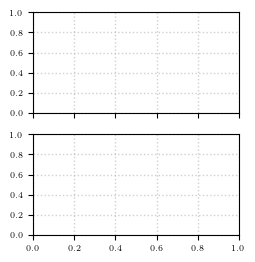

In [5]:
# Plot single RB decay and fit to model
def plot_data_fit(ax, df, model_func, popt):
    x_min = 1
    x_max = max(df["Clifford Length"]) * 1.2
    ax.errorbar(df["Clifford Length"], df["P00"], yerr=df["P00 Std"], fmt="^", label="$P_{00}$", color=gs.get_color(0))
    #ax.errorbar(df["Clifford Length"], df["P01"], yerr=df["P01 Std"], fmt="^", label="P01", color=gs.get_color(1))
    #ax.errorbar(df["Clifford Length"], df["P10"], yerr=df["P10 Std"], fmt="^", label="P10", color=gs.get_color(2))
    ax.errorbar(df["Clifford Length"], df["P11"], yerr=df["P11 Std"], fmt="^", label="$P_{11}$", color=gs.get_color(3))
    P0110 = [a+b for a, b in zip(df["P01"], df["P10"])]
    P0110_std = [np.sqrt(a**2 + b**2) for a, b in zip(df["P01 Std"], df["P10 Std"])]
    ax.errorbar(df["Clifford Length"], P0110, yerr=P0110_std, fmt="^", label="$P_{01}+P_{10}$", color=gs.get_color(2))
    x_fit = np.logspace(np.log10(min(df["Clifford Length"])), np.log10(max(df["Clifford Length"])), 100)
    p0 = [0.6537, 0.05, 1.6918, 0.02]
    P_fit = model_func(x_fit, *popt).reshape(4, -1)
    
    ax.plot(x_fit, P_fit[0], color=gs.get_color(0), alpha=gs.get_alpha())
    #ax.plot(x_fit, P_fit[1], color=gs.get_color(1), alpha=gs.get_alpha())
    #ax.plot(x_fit, P_fit[2], color=gs.get_color(2), alpha=gs.get_alpha())
    ax.plot(x_fit, P_fit[3], color=gs.get_color(3), alpha=gs.get_alpha())
    P0110_fit = P_fit[1] + P_fit[2]
    ax.plot(x_fit, P0110_fit, color=gs.get_color(2), alpha=gs.get_alpha())
    ax.hlines(0.25, x_min, x_max, color="gray", linestyle="--", alpha=0.5)
    ax.hlines(0.5, x_min, x_max, color="gray", linestyle="--", alpha=0.5)
    ax.hlines(0.333, x_min, x_max, color=gs.get_color(4), linestyle="--", alpha=0.5)

    ax.set_ylabel("Populations")
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(-0.04, 1.0)
    ax.set_xscale("log")
    # place legend in upper right corner
    ax.legend(loc="upper right")

m = fh.PTMModel()
#m = fh.GTModel()
fig_width = 1 / (gs.get_phi() + 1) * gs.get_fig_width() - margin

fig_height = 1. / (gs.get_phi() + 1) * gs.get_fig_width()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(fig_width, fig_height), sharex=True)

#gs.place_letter(fig, "b")


date = "2026-02-05"
rid = 93319
sim_outcomes = [1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, ]
#sim_outcomes = np.zeros(len(sim_outcomes))
df, popt, pcov = m.rb_to_fits(date, rid, sim_outcomes)
plot_data_fit(ax1, df, m.model, popt)

# plot parities
cliffords = [50, 25, 12,  100, 200, 400, 800, 6, 3, 1600, 8, 2, 3200]
par_contrast = [
    0.5738,
    0.5967,
    0.5525,
    0.5551,
    0.4517,
    0.3674,
    0.1941,
    0.3287,
    0.2634,
    0.1025,
    0.4192,
    0.1997,
    0.0213,
]
par_contrast_err = [
    0.0343,
    0.0344,
    0.0273,
    0.0433,
    0.0373,
    0.0309,
    0.0118,
    0.0274,
    0.0577,
    0.0261,
    0.0268,
    0.0318,
    0.0304,
]

p_parity = ax2.errorbar(cliffords, par_contrast, yerr=par_contrast_err, color=gs.get_color(5), fmt="^")

def parity_model(x, g, l):
    term1 = (1 - (2*l**2)/3)**x
    term2 = (1 - g**2 - (2*l**2)/3)**x
    return (2/3) * (term1 - term2)

p0 = popt[:2]  # Initial guess for l and g from the previous fit
print(p0)
sim_line = np.logspace(np.log10(min(cliffords)), np.log10(max(cliffords)), 100)
popt, pcov = curve_fit(parity_model, cliffords, par_contrast, p0=p0)
fitted_parity = parity_model(sim_line, *p0)#fitted_model.param)
print(f"Fitted Parity Model Parameters: θ_g = {popt[0]}, θ_l = {popt[1]}" )
ax2.plot(sim_line, fitted_parity, color=gs.get_color(5), alpha=gs.get_alpha())
# set y labels and limits to 0 1/3, 2/3
ax2.set_ylabel("Parity contrast")
ax2.set_ylim(0, 0.7)
ax2.set_yticks([0, 1/3, 2/3])
ax2.set_yticklabels(["0", r"$\frac{1}{3}$", r"$\frac{2}{3}$"])

ax2.set_xlabel("Sequence length, $m$")
ax.set_xticks([])
f_path = "..\\pdf_figure\\f2_parity.pdf"
fig.savefig(f_path)

# param1, param2, param3, param4 = popt
# param1_err, param2_err, param3_err, param4_err = np.sqrt(np.diag(pcov))
# print(f"{m.p1_name}: {param1:.4f} ± {param1_err:.4f}")
# print(f"{m.p2_name}: {param2:.4f} ± {param2_err:.4f}")
# print(f"{m.p3_name}: {param3:.4f} ± {param3_err:.4f}")
# print(f"{m.p4_name}: {param4:.4f} ± {param4_err:.4f}")


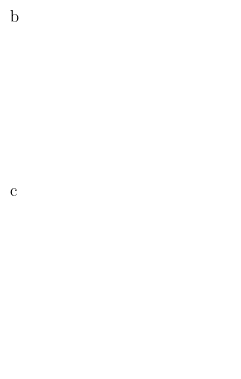

In [71]:
fig_width = (1/3)*gs.get_fig_width() - margin
fig_height = (5/6)*gs.get_fig_width() / gs.get_phi()
fig, ax = plt.subplots(ncols=1, nrows=1, figsize=(fig_width, fig_height), layout="constrained")
gs.place_letter(fig, "b")
gs.place_letter(fig, "c", y = 0.52)
# turn off axis
ax.axis("off")
f_path = "..\\pdf_figure\\f2_fit_sensitivity.pdf" 
fig.savefig(f_path)


In [72]:
# Debug plots
def plot_data_fit(df, model_func, popt):
    plt.errorbar(df["Clifford Length"], df["P00"], yerr=df["P00 Std"], fmt="^", label="P00", color=gs.get_color(0))
    plt.errorbar(df["Clifford Length"], df["P01"], yerr=df["P01 Std"], fmt="^", label="P01", color=gs.get_color(1))
    plt.errorbar(df["Clifford Length"], df["P10"], yerr=df["P10 Std"], fmt="^", label="P10", color=gs.get_color(2))
    plt.errorbar(df["Clifford Length"], df["P11"], yerr=df["P11 Std"], fmt="^", label="P11", color=gs.get_color(3))

    x_fit = np.linspace(min(df["Clifford Length"]), max(df["Clifford Length"]), 100)
    P_fit = model_func(x_fit, *popt).reshape(4, -1)
    plt.plot(x_fit, P_fit[0], color=gs.get_color(0), alpha=gs.get_alpha())
    plt.plot(x_fit, P_fit[1], color=gs.get_color(1), alpha=gs.get_alpha())
    plt.plot(x_fit, P_fit[2], color=gs.get_color(2), alpha=gs.get_alpha())
    plt.plot(x_fit, P_fit[3], color=gs.get_color(3), alpha=gs.get_alpha())

    plt.xlabel("Clifford Length")
    plt.ylabel("Population")
    plt.legend()
    plt.show()

date = "2026-01-29"
rid = 92541
sim_outcomes = [1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, ]
model = fh.ptm_model
p0 = [0.01, 0.01, 0.01, 0.01]
bounds = ([0.0, 0.0, 0.0, 0.0], [1.0, 1.0, 1.0, 1.0])

df, popt, pcov = fh.rb_to_fits(date, rid, sim_outcomes, model, p0, bounds)
theta_g, theta_l1, theta_l2, spam = popt
theta_g_err, theta_l1_err, theta_l2_err, spam_err = np.sqrt(np.diag(pcov))
print(f"Global noise (theta_g): {theta_g:.4f} ± {theta_g_err:.4f}")
print(f"Local noise (theta_l1): {theta_l1:.4f} ± {theta_l1_err:.4f}")
print(f"Local noise (theta_l2): {theta_l2:.4f} ± {theta_l2_err:.4f}")
print(f"SPAM error: {spam:.4f} ± {spam_err:.4f}")
plot_data_fit(df, model, [0.46, 0.16, 0.0, 0])#]popt)

AttributeError: module 'fig_helper' has no attribute 'ptm_model'

In [ ]:
def nn2cd(theta_nn, theta_1, theta_2):
    """ 
    Go from parameterization
    theta_1, theta_2, theta_nn -> theta_com, theta_diff
    """
    def rod_form(theta, n):
        return np.cos(theta)*np.identity(3) + (1 - np.cos(theta))*np.outer(n, n) + np.sin(theta)*np.array([[0, -n[2], n[1]], [n[2], 0, -n[0]], [-n[1], n[0], 0]])

    def rot_angle(R):
        return np.arccos((np.trace(R) - 1) / 2)

    def rot_axis(R):
        theta = rot_angle(R)
        if theta == 0:
            return np.array([1, 0, 0])
        return np.array([(R[2, 1] - R[1, 2]) / (2 * np.sin(theta)),
                        (R[0, 2] - R[2, 0]) / (2 * np.sin(theta)),
                        (R[1, 0] - R[0, 1]) / (2 * np.sin(theta))])

    R1 = rod_form(theta_1, [0, 0, 1])
    R2 = rod_form(theta_2, [np.sin(theta_nn), 0, np.cos(theta_nn)])
    Rs = R2 @ np.linalg.inv(R1)
    theta_diff = rot_angle(Rs)/2
    n_d = rot_axis(Rs)

    Rc = R1 @ np.linalg.inv(rod_form(-theta_diff, n_d))
    theta_com = rot_angle(Rc)
    n_c = rot_axis(Rc)
    theta_cd = np.acos(np.dot(n_c, n_d))
    return theta_com, theta_diff, theta_cd

theta_1 = 0.1
theta_2 = 0.2
theta_nn = 0.6
theta_com, theta_diff, theta_cd = nn2cd(theta_nn, theta_1, theta_2)
print(f"theta_com: {theta_com:.4f}, theta_diff: {theta_diff:.4f}, theta_cd: {theta_cd:.4f}")


theta_com: 0.1441, theta_diff: 0.0651, theta_cd: 0.6451
0.5235987755982989


In [ ]:
import numpy as np

def rod_form(theta, n):
    """ Rodrigues' rotation formula to get rotation matrix from angle and axis"""
    return np.cos(theta)*np.identity(3) + (1 - np.cos(theta))*np.outer(n, n) + np.sin(theta)*np.array([[0, -n[2], n[1]], [n[2], 0, -n[0]], [-n[1], n[0], 0]])


def rot_angle(R):
    # clamp trace-derived cosine to avoid NaNs from floating point drift
    val = (np.trace(R) - 1.0) / 2.0
    val = max(-1.0, min(1.0, val))
    return np.arccos(val)

def rot_axis(R):
    theta = rot_angle(R)
    if abs(theta) < 1e-8:
        # arbitrary axis when rotation is (near) identity
        return np.array([1.0, 0.0, 0.0])
    s = 2.0 * np.sin(theta)
    return np.array([(R[2,1] - R[1,2]) / s,
                     (R[0,2] - R[2,0]) / s,
                     (R[1,0] - R[0,1]) / s])

def nn2cd(theta_nn, theta_1, theta_2):
    """
    Forward map:
      (theta_nn, theta_1, theta_2) -> (theta_com, theta_diff, theta_cd)

    n1 = (0,0,1)
    n2 = (sin(theta_nn), 0, cos(theta_nn))
    """
    R1 = rod_form(theta_1, [0.0, 0.0, 1.0])
    R2 = rod_form(theta_2, [np.sin(theta_nn), 0.0, np.cos(theta_nn)])
    Rs = R2 @ np.linalg.inv(R1)
    phi = rot_angle(Rs)
    theta_diff = phi / 2.0
    n_d = rot_axis(Rs)
    # Rc chosen so that R1 = Rc * Rd
    Rc = R1 @ np.linalg.inv(rod_form(-theta_diff, n_d))
    theta_com = rot_angle(Rc)
    n_c = rot_axis(Rc)
    # angle between axes (clamped)
    theta_cd = np.arccos(np.clip(np.dot(n_c, n_d), -1.0, 1.0))
    return float(theta_com), float(theta_diff), float(theta_cd)

def cd2nn(theta_com, theta_diff, theta_cd):
    """
    Inverse map (one canonical choice):
      (theta_com, theta_diff, theta_cd) -> (theta_nn, theta_1, theta_2)

    Strategy:
      - pick n_c = e_z, pick n_d in xz-plane so angle(n_c,n_d)=theta_cd
      - form Rc = Rot(theta_com, n_c), Rd = Rot(-theta_diff, n_d)
      - build R1 = Rc*Rd, R2 = Rc*Rd^{-1}
      - find rotation Q that maps axis(R1) -> e_z (so R1 becomes single-axis about e_z)
      - conjugate R1,R2 by Q and extract theta_1 (from R1) and theta_2 (from R2)
      - extract theta_nn from axis of R2 after conjugation (axis should be in xz-plane by construction)
    """
    # choose canonical axes in internal representation
    n_c = np.array([0.0, 0.0, 1.0])
    n_d = np.array([np.sin(theta_cd), 0.0, np.cos(theta_cd)])  # x positive convention

    Rc = rod_form(theta_com, n_c)
    Rd = rod_form(-theta_diff, n_d)

    R1 = Rc @ Rd
    R2 = Rc @ np.linalg.inv(Rd)

    # compute axis of R1 and rotation Q that maps it to e_z
    n1p = rot_axis(R1)
    ez = np.array([0.0, 0.0, 1.0])
    cross = np.cross(n1p, ez)
    if np.linalg.norm(cross) < 1e-8 and np.dot(n1p, ez) > 0.9999999:
        Q = np.eye(3)
    else:
        v = cross
        vnorm = np.linalg.norm(v)
        if vnorm < 1e-12:
            # n1p nearly opposite ez: rotate pi about x (arbitrary choice)
            Q = rod_form(np.pi, np.array([1.0, 0.0, 0.0]))
        else:
            v = v / vnorm
            ang = np.arccos(np.clip(np.dot(n1p, ez), -1.0, 1.0))
            Q = rod_form(ang, v)

    # conjugate so R1 is about ez
    R1p = Q @ R1 @ np.linalg.inv(Q)
    R2p = Q @ R2 @ np.linalg.inv(Q)

    # extract final parameters
    theta_1 = rot_angle(R1p)
    theta_2 = rot_angle(R2p)
    n2p = rot_axis(R2p)

    # recover theta_nn from axis of R2p: axis is (sin(theta_nn), 0, cos(theta_nn)) up to numerical noise.
    theta_nn = np.arctan2(n2p[0], n2p[2])  # signed; bias toward positive x
    if theta_nn < 0:
        # force positive x by reflecting about z-axis (equivalent representation)
        theta_nn = -theta_nn
        Ry = rod_form(np.pi, np.array([0.0, 1.0, 0.0]))
        R1p = Ry @ R1p @ np.linalg.inv(Ry)
        R2p = Ry @ R2p @ np.linalg.inv(Ry)
        theta_1 = rot_angle(R1p)
        theta_2 = rot_angle(R2p)

    # clamp into range [0, pi]
    theta_nn = float(np.clip(theta_nn, 0.0, np.pi))
    return theta_nn, float(theta_1), float(theta_2)

theta_nn = 0.1
theta_1 = 0.0
theta_2 = 0.1
print(f"theta_nn: {theta_nn:.4f}, theta_1: {theta_1:.4f}, theta_2: {theta_2:.4f}")

theta_com, theta_diff, theta_cd = nn2cd(theta_nn, theta_1, theta_2)
print(f"theta_com: {theta_com:.4f}, theta_diff: {theta_diff:.4f}, theta_cd: {theta_cd:.4f}")

theta_nn_rec, theta_1_rec, theta_2_rec = cd2nn(theta_com, theta_diff, theta_cd)
print(f"theta_nn_rec: {theta_nn_rec:.4f}, theta_1_rec: {theta_1_rec:.4f}, theta_2_rec: {theta_2_rec:.4f}")

theta_nn: 0.1000, theta_1: 0.0000, theta_2: 0.1000
theta_com: 0.0500, theta_diff: 0.0500, theta_cd: 0.0000
theta_nn_rec: 1.5708, theta_1_rec: 0.0000, theta_2_rec: 0.1000
